In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation
from IPython.display import HTML

Initial Condition

Left State:

    rhoL = 1.0 

    velL = 0.0

    preL = 1.0

Right State:

    rhoR = 0.125

    velR = 0.0

    preR = 0.1


## HLL

In [5]:
def prepareanimation():
    global figA, artistA
    #set up for animation
    figA = plt.figure(figsize=(8,6))
    artistA = []

    plt.xlim(-0.5*1,0.5*1)
    plt.xlabel(r'$x$')

In [6]:
def addanimation(cel_center, rho, u, p, legend):

    global artistA
    
    im1 = plt.plot(cel_center, rho, color='blue',label=r"$\rho$",)
    im2 = plt.plot(cel_center, u, color='red',label=r"$v$",)
    im3 = plt.plot(cel_center, p, color='green',label=r"$P$")

    plt.xlabel(r'$x$')
    plt.xlim(min(cel_center), max(cel_center))
    plt.ylim(-0.1, 1.2)
    
    if legend == 1:
        plt.legend()

    figA.tight_layout()
    artistA.append(im1 + im2 + im3)

In [7]:
def godunov(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe):
    
    for i in range(ist, ien-1):
        rho[i] = rho[i] - dt/dx*( frho[i] - frho[i-1] )
        mom[i] = mom[i] - dt/dx*( fmom[i] - fmom[i-1] )
        ene[i] = ene[i] - dt/dx*( fe[i] - fe[i-1] )

## HLLC

In [111]:
def prepareanimation():
    global figA, artistA
    #set up for animation
    figA = plt.figure(figsize=(8,6))
    artistA = []

    #plt.xlim(-0.5*1,0.5*1)
    plt.xlabel(r'$x$')

In [112]:
def addanimation(cel_center, rho, u, p, legend):

    global artistA
    
    im1 = plt.plot(cel_center, rho, color='red',label=r"$\rho$",)
    im2 = plt.plot(cel_center, u, color='green',label=r"$v$",)
    im3 = plt.plot(cel_center, p, color='blue',label=r"$P$")

    plt.xlabel(r'$x$')
    plt.xlim(min(cel_center), max(cel_center))
    plt.ylim(-0.1, 1.2)
    
    if legend == 1:
        plt.legend()

    figA.tight_layout()
    
    artistA.append(im1 + im2 + im3)

In [209]:
def godunov(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe):
    #print(len(frho))
    
    for i in range(ist, ien):

        rho[i] = rho[i] - dt/dx*( frho[i] - frho[i-1] )
        mom[i] = mom[i] - dt/dx*( fmom[i] - fmom[i-1] )
        ene[i] = ene[i] - dt/dx*( fe[i] - fe[i-1] ) 

    return rho,mom,ene 

In [188]:
def newtonraphson(uL, uR, pR, pL, cL, cR):
    global gamma
    ## vL(p)=vR(p)
    #f(p) = vL(p) - vR(p)
    gamma = 1.4

    p_i = ( cR*pL + cL*pR - cR*cL*(uR - uL) )/(cR + cL)
    
    if p_i<0:p_i = 1e-8
    
    delta = 10
    dp_Ldv=0
    dp_Rdv=0
    vL = 0
    vR = 0
    
    while abs(delta) > 1e-4:
        mass_flux_L = 0.5*cL**2*((gamma+1)*p_i/pL + (gamma -1))/gamma
        dp_Ldv = 2*mass_flux_L*np.sqrt(mass_flux_L)/(mass_flux_L + cL**2)
        
        mass_flux_R = 0.5*cR**2*((gamma+1)*p_i/pR + (gamma -1))/gamma
        dp_Rdv = 2*mass_flux_R*np.sqrt(mass_flux_R)/(mass_flux_R + cR**2)
        
        vL = uL - (p_i - pL)/np.sqrt(mass_flux_L)
        vR = uR + (p_i - pR)/np.sqrt(mass_flux_R) 

        delta = dp_Ldv* dp_Rdv*(vR - vL)/ ( (dp_Ldv + dp_Rdv)*p_i)
        p_i = p_i*(1.0 - delta)

    return p_i, (dp_Ldv*vL+ dp_Rdv*vR)/(dp_Ldv + dp_Rdv)

In [ ]:
def hllc(rhoL, uL, pL, rhoR, uR, pR):

    global gamma

    rhoL = rhoL
    uL = uL
    pL = pL 

    rhoR = rhoR
    uR = uR
    pR = pR

    gamma = 1.4
   
    s = np.zeros(3)

    cL = np.sqrt(gamma*pL*rhoL)

    cR = np.sqrt(gamma*pR*rhoR)
     
    p_star, v_star = newtonraphson(uL, uR, pR, pL, cL, cR)
    

    aL = np.sqrt(gamma * pL / rhoL)
    aR = np.sqrt(gamma * pR / rhoR)
    
    if p_star >= pL: #shock
        rho_star_l = rhoL*(p_star/pL + (gamma-1)/(gamma+1))/( (gamma-1)/(gamma+1)*p_star/pL + 1.0)
        s[0] = uL - aL*np.sqrt( ( (gamma + 1)*p_star/pL + (gamma+1) )/(2.0*gamma) )
        
    else: #rarefaction
        rho_star_l = rhoL * (p_star/pL)**(1/gamma)
        s[0] = 0.5*( uL - aL + v_star - np.sqrt(gamma*p_star/rho_star_l) )
        

    if p_star >= pR: #shock
        rho_star_r = rhoR*(p_star/pR + (gamma-1)/(gamma+1))/( (gamma-1)/(gamma+1)*p_star/pR + 1.0)
        s[2] = uR + aR*np.sqrt( ( (gamma + 1)*p_star/pR + (gamma+1) )/(2.0*gamma) )
        
    else: #rarefaction
        rho_star_r = rhoR * (p_star/pR)**(1/gamma)
        s[2] = 0.5*( uR + aR + v_star + np.sqrt(gamma*p_star/rho_star_r) )
        


    #s[0] = min(uL - np.sqrt(gamma*pL/rhoL), uR - np.sqrt(gamma*pR/rhoR))
    #s[2] = max(uL + np.sqrt(gamma*pL/rhoL), uR + np.sqrt(gamma*pR/rhoR))

    
    s[1] = v_star


    if s[0] >= 0: #wL
        frho =  rhoL * uL
        fmom= rhoL * uL**2 + pL
        fe = (gamma*pL/(gamma-1) + 0.5*rhoL*uL**2) * uL

    elif s[1] >= 0: #wL*
        frho =  rho_star_l * v_star
        fmom= rho_star_l * v_star**2 + p_star
        fe = (gamma*p_star/(gamma-1) + 0.5*rho_star_l*v_star**2) * v_star

    elif s[2] >= 0: #wR*
        frho =  rho_star_r * v_star
        fmom= rho_star_r * v_star**2 + p_star
        fe = (gamma*p_star/(gamma-1) + 0.5*rho_star_r*v_star**2) * v_star

    else:  #wR
        frho =  rhoR * uR
        fmom= rhoR * uR**2 + pR
        fe = (gamma*pR/(gamma-1) + 0.5*rhoR*uR**2) * uR

    return frho, fmom, fe

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9999999999999997
0.9999999999999976
0.9999999999999823
0.99999999999987
0.9999999999990397
0.9999999999929046
0.9999999999475719
0.9999999996126062
0.9999999971375263
0.9999999788490227
0.9999998437142812
0.9999988451981852
0.9999914672208539
0.999936957162342
0.9995345191137517
0.9965793123456634
0.975701856841808
0.8597206540951923
0.5684578506980169
0.2528382148640846
0.12502377014632993
0.10343827558639535
0.10046581788413765
0.10006304904891973
0.10000853289300661
0.1000011548039006
0.10000015628575704
0.10000002115097806
0.1000000028624737
0.1000000003873937
0.10000000005242804
0.10000000000709541
0.10000000000096027
0.10000000000012993
0.10000000000001757
0.10000000000000236
0.10000000000000026
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.09999999999999998
0.0999999999999

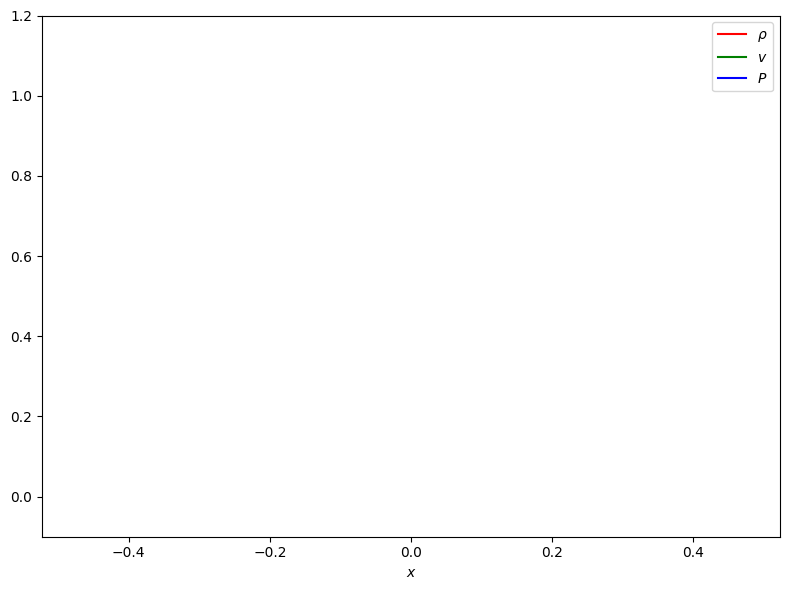

In [208]:
def shocktube1d(rhoL,velL,preL,rhoR,velR,preR):
    
    global ist, ien, dx, ntot, gamma, L

    #initial conditions
    rhoL = rhoL 
    uL = velL
    pL = preL

    rhoR = rhoR
    uR = velR
    pR = preR

    ngrids = 64
    L = 1.0
    dx = L / ngrids
    cfl = 0.8
    gamma = 1.4
     
    ist = 2
    nghost = ist
    ien = ngrids + nghost
    ntot = ngrids + 2*nghost
    cfl = 0.5

    rho = np.zeros(ntot)
    u = np.zeros(ntot)
    p = np.zeros(ntot)

    #fluxes
    global frho, frhou, fe
    frho = np.zeros(ntot)
    fmom = np.zeros(ntot)
    fe = np.zeros(ntot)

    mom = np.zeros(ntot)
    ene = np.zeros(ntot)

    time = 0
    tout = 0.25
    dt_plot = 0.01
    prepareanimation()


    cel_center = np.zeros(ntot)
    cel_boundary = np.zeros(ntot+1)

    for i in range(ntot +1):
        cel_boundary[i] = -0.5*L + (i-ist)*dx

    for i in range(ntot):
        cel_center[i] = 0.5*(cel_boundary[i] + cel_boundary[i+1])

    #profile at t = 0
    x0 = ngrids//2.0 # center of the shock tube

    for i in range(ntot):
        """
        if i <= x0:
            rho[i] = rhoL
            u[i] = uL
            p[i] = pL

        else:
            rho[i] = rhoR
            u[i] = uR
            p[i] = pR
        """
        rho[i] = (rhoR - rhoL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + rhoL
        u[i] = (velR - velL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + velL
        p[i] = (preR - preL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + preL

        mom[i] = rho[i]*u[i]
        ene[i] = p[i]/(gamma-1) + 0.5*rho[i]*u[i]**2

    
    addanimation(cel_center, rho, u, p,1)


    rhoL = np.zeros(ntot)   
    rhoR = np.zeros(ntot)  
    uL = np.zeros(ntot) 
    uR = np.zeros(ntot)   
    pL = np.zeros(ntot)  
    pR = np.zeros(ntot)   




    dt = cfl*np.min(dx/(np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien])))
    

    time_plot = 0

    while time < tout:
        
            # calculate w_{i+1/2,L}
        for i in range(ist-1,ien):
            rhoL[i] = rho[i]
            uL[i] = u[i]
            pL[i] = p[i]

        # calculate u_{i+1/2,R}
        for i in range(ist-1,ien):
            rhoR[i] = rho[i+1]
            uR[i] = u[i+1]
            pR[i] = p[i+1]

        for i in range(ist-1, ien):
            frho[i], fmom[i], fe[i] = hllc(rhoL[i], uL[i], pL[i], rhoR[i], uR[i], pR[i])
        
        rho, mom, ene = godunov(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe)

        for i in range(ist, ien):
            u[i] = mom[i]/rho[i]
            p[i] = (gamma-1)*(ene[i] - 0.5*rho[i]*u[i]**2)  #(ene[i] - 0.5*mom[i]*u[i])/rho[i]
        
        time = time + dt
        time_plot = time_plot + dt
        
        #print(time)
        if time_plot > dt_plot:
            addanimation(cel_center, rho, u, p,0)
            time_plot = 0.0

        dt = cfl*np.min(dx/(np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien])))
        
        if  time + dt > tout:
            dt = tout - time
        
    addanimation(cel_center, rho, u, p,0)


if __name__ == "__main__":
    shocktube1d(rhoL = 1.0 ,velL= 0.0, preL=1.0 ,rhoR=0.125 ,velR=0.0 ,preR=0.1)

anim = ArtistAnimation(figA, artistA, interval=100) 
HTML(anim.to_jshtml())  